Hyundai Motor Company Stock Analysis

objective
This notebook performs exploratory data analysis (EDA) on Hyundai Motor Comapany's Historical stock prices.

Goals:
- Understand price trends over time
- Analyze volatility and returns
- Study trading volume behavior
- Identify Statistical patterns

IMPORTANT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

LOAD DATASET

In [16]:
df = pd.read_csv("005380.KS.csv")
df.head()

,Date,open,high,low,close,adjclose,volume,ingested_at_utc
0,2016-01-04,147500.0,148000.0,143500.0,144000.0,102446.257812,445332,2026-02-21 06:47:26.527494+00:00
1,2016-01-05,143000.0,145000.0,142000.0,143500.0,102090.546875,530496,2026-02-21 06:47:26.527494+00:00
2,2016-01-06,144000.0,145000.0,139000.0,140000.0,99600.523438,769406,2026-02-21 06:47:26.527494+00:00
3,2016-01-07,138500.0,140000.0,137500.0,137500.0,97821.921875,586187,2026-02-21 06:47:26.527494+00:00
4,2016-01-08,134500.0,138000.0,133500.0,136500.0,97110.500000,888701,2026-02-21 06:47:26.527494+00:00


BASIC DATA INSPECTION

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2481 entries, 0 to 2480
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             2481 non-null   str    
 1   open             2480 non-null   float64
 2   high             2480 non-null   float64
 3   low              2480 non-null   float64
 4   close            2480 non-null   float64
 5   adjclose         2480 non-null   float64
 6   volume           2481 non-null   int64  
 7   ingested_at_utc  2481 non-null   str    
dtypes: float64(5), int64(1), str(2)
memory usage: 155.2 KB


In [18]:
df.describe()

,open,high,low,close,adjclose,volume
count,2480.000000,2480.000000,2480.000000,2480.000000,2480.000000,2.481000e+03
mean,177381.774194,179858.629032,174998.790323,177376.814516,149149.659981,8.788348e+05
std,55285.693492,56739.643461,53927.489139,55312.796171,60708.498618,9.597945e+05
min,67200.000000,71000.000000,65000.000000,65900.000000,52819.722656,0.000000e+00
25%,137500.000000,139000.000000,135500.000000,137000.000000,101379.109375,4.360450e+05
50%,171500.000000,173000.000000,169000.000000,170500.000000,142020.906250,6.091700e+05
75%,207125.000000,210000.000000,205000.000000,207500.000000,180725.886719,9.459270e+05
max,586000.000000,590000.000000,525000.000000,549000.000000,549000.000000,1.993370e+07


In [19]:
df.isnull().sum()

Date               0
open               1
high               1
low                1
close              1
adjclose           1
volume             0
ingested_at_utc    0
dtype: int64

DATA CLEANING & FORMATTING

In [20]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

SORT BY DATE 

In [21]:
df.sort_index(inplace=True)

TIME SERIES VISUALIZATION

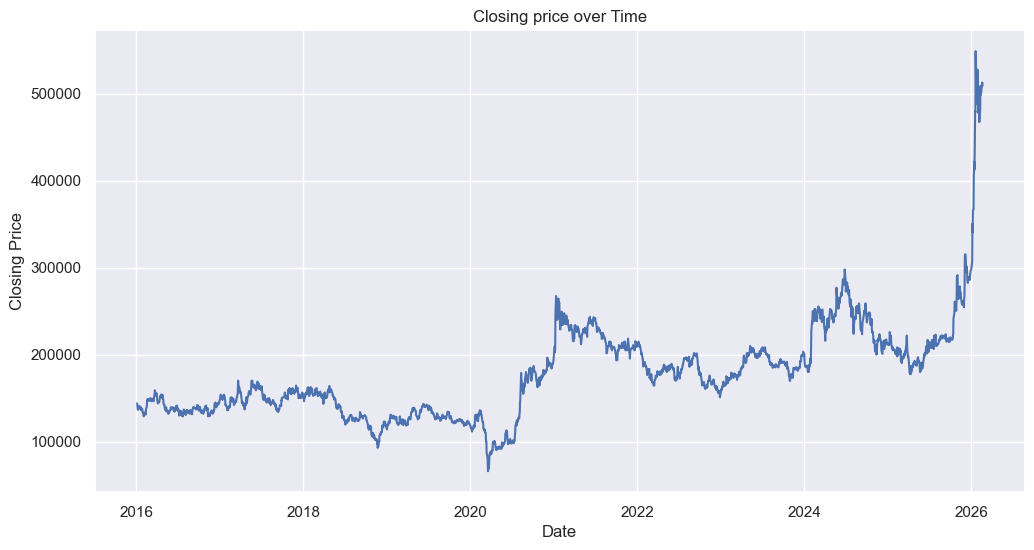

In [22]:
plt.figure(figsize=(12,6))
plt.plot(df["close"])
plt.title("Closing price over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

VOLUME TREND

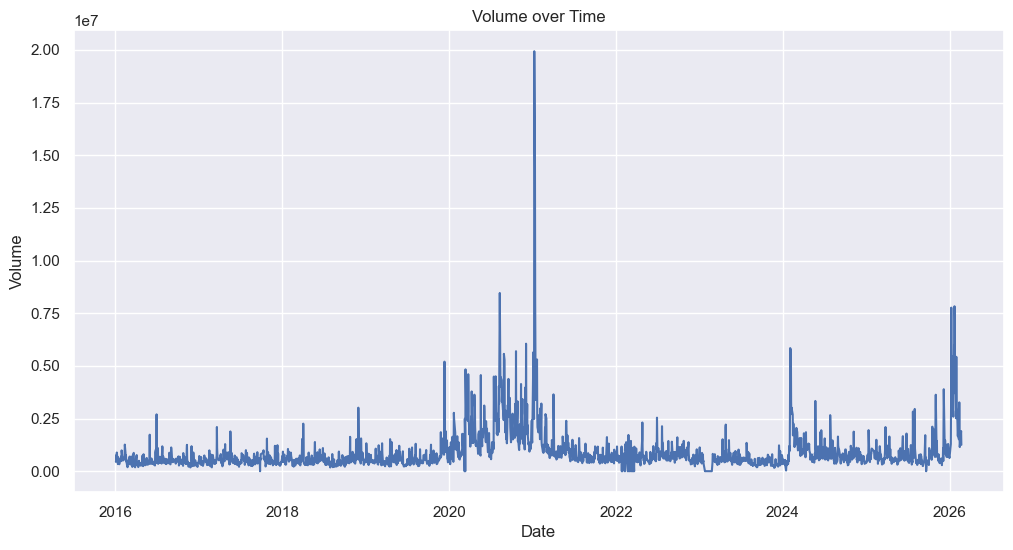

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(df["volume"])
plt.title("Volume over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

DAILY RETURN

In [24]:
df["MA_20"] = df["close"].rolling(window=20).mean()

PLOT WITH MA

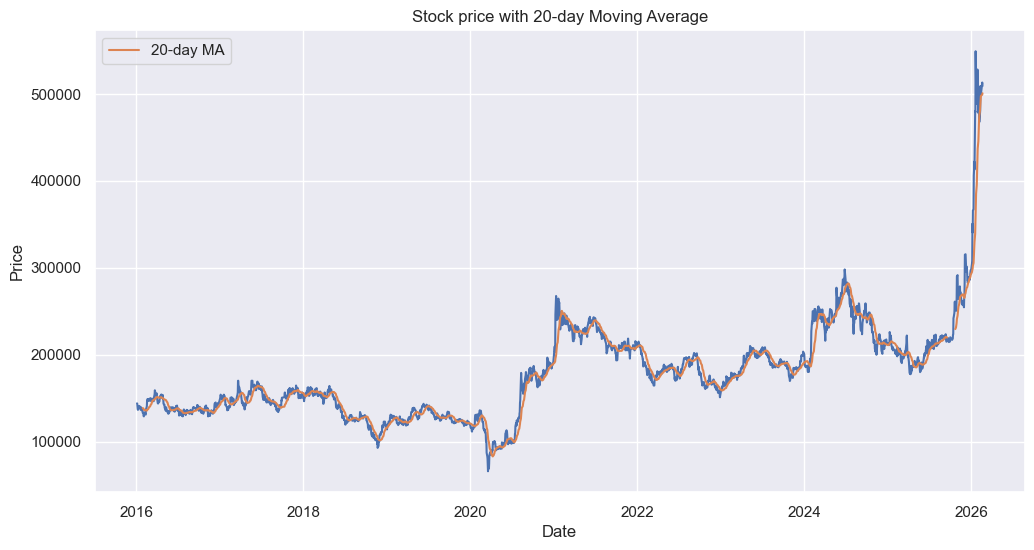

In [25]:
plt.figure(figsize=(12,6))
plt.plot(df["close"])
plt.plot(df["MA_20"], label="20-day MA")
plt.legend()
plt.title("Stock price with 20-day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

VOLATILITY ANALYSIS

In [31]:
df["Daily_Return"] = df["close"].pct_change()

In [32]:
df["Volatility"] = df["Daily_Return"].rolling(window=20).std()

df[["Daily_Return", "Volatility"]].head(25)

,Daily_Return,Volatility
Date,,
2016-01-04,NaN,NaN
2016-01-05,-0.003472,NaN
2016-01-06,-0.024390,NaN
2016-01-07,-0.017857,NaN
2016-01-08,-0.007273,NaN
2016-01-11,0.025641,NaN
2016-01-12,-0.003571,NaN
2016-01-13,0.007168,NaN
2016-01-14,0.003559,NaN


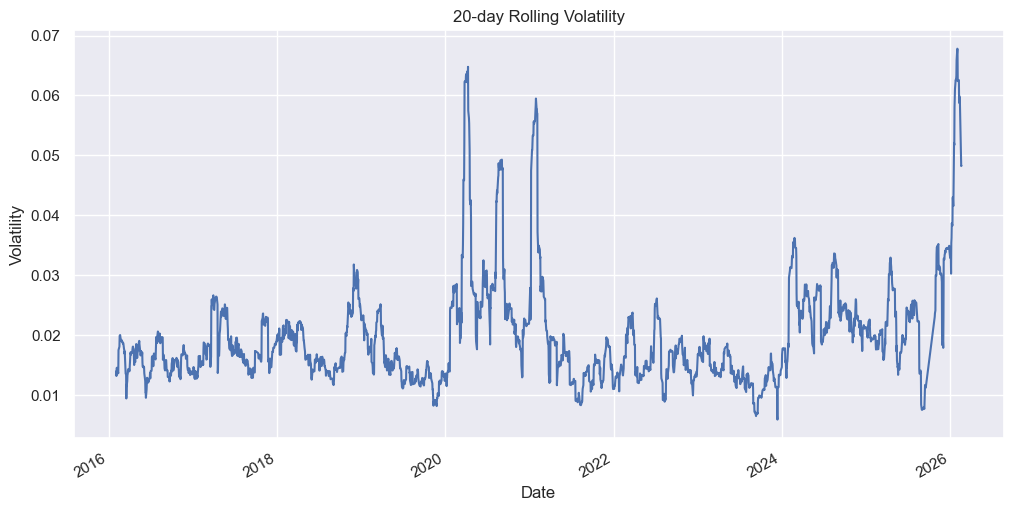

In [33]:
plt.figure(figsize=(12,6))
df["Volatility"].dropna().plot()
plt.title("20-day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

CORRELATION

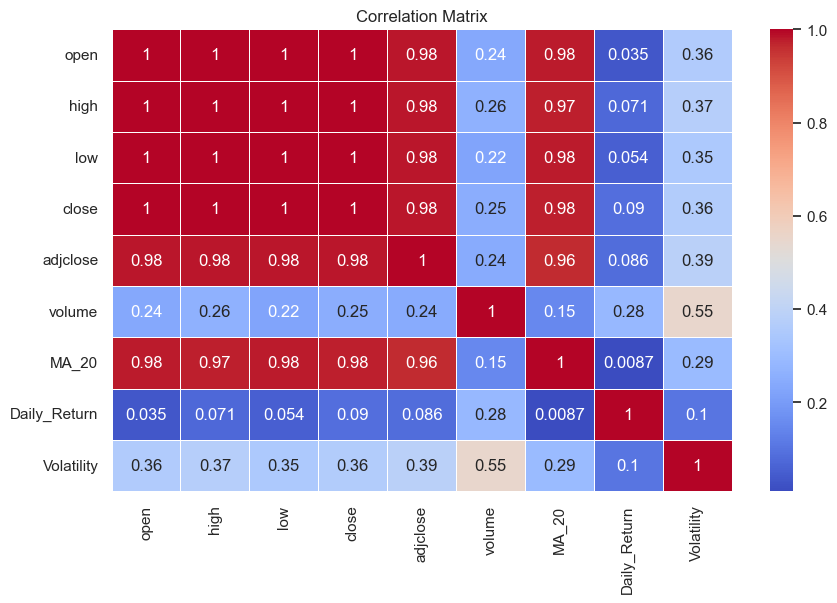

In [37]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

STATISTICAL ANALYSIS

In [35]:
df["Daily_Return"].dropna().describe()

count    2478.000000
mean        0.000737
std         0.021643
min        -0.128000
25%        -0.010690
50%         0.000000
75%         0.010133
max         0.194175
Name: Daily_Return, dtype: float64

## Key Observations

- The stock shows long-term upward/downward trend.
- Volatility spikes during certain periods.
- Volume increases during major price movements.
- Daily returns show moderate variance.

## Conclusion

The analysis reveals price trends, volatility behavior, and trading activity patterns in Hyundai’s stock. 
Further steps could include predictive modeling or forecasting using ARIMA or machine learning models.